# Exercise 30.2a solution


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Model parameters
R_T = 1
k_0_on = 0
k_0_off = 100
k_Ca_on = 120
k_Ca_off = 50
Ca_50 = k_Ca_off / k_Ca_on

f_0 = 50
f_prime_0 = 400
h = 8
h_prime = 6
g = 4

u = 8
v = 2
w = 3

Ca = Ca_50 * 100

In [3]:
def rhs_cooperative(t, y, Ca, u, v, w):
    """Right-hand side of the cooperative Razumova model."""
    D, A_1, A_2 = y

    # Ca-dependent base rates
    k_u_on = k_0_on + (k_Ca_on - k_0_on) * Ca / (Ca_50 + Ca)
    k_u_off = k_0_off + (k_Ca_off - k_0_off) * Ca / (Ca_50 + Ca)

    # State subpopulations
    R_off = R_T - D - A_1 - A_2
    lambda_A2 = A_2 / R_T
    lambda_on = (D + A_1 + A_2) / R_T

    # XB-XB cooperativity (parameter v)
    f = f_0 * (1 + lambda_A2 * (np.exp(v - 1) - 1)) ** 2
    f_prime = f_prime_0 * (1 + lambda_A2 * (np.exp(-(v - 1)) - 1)) ** 2

    # RU-RU cooperativity (parameter u)
    k_w_on = k_u_on * (1 + lambda_on * (u - 1)) ** 2
    k_w_off = k_u_off * (u - lambda_on * (u - 1)) ** 2

    # XB-RU cooperativity (parameter w)
    k_on = k_w_on * (1 + lambda_A2 * (np.exp(w - 1) - 1)) ** 2
    k_off = k_w_off * (1 + lambda_A2 * (np.exp(-(w - 1)) - 1)) ** 2

    # ODEs
    dD_dt = k_on * R_off + f_prime * A_1 + g * A_2 - (k_off + f) * D
    dA1_dt = f * D + h_prime * A_2 - (f_prime + h) * A_1
    dA2_dt = h * A_1 - (h_prime + g) * A_2

    return [dD_dt, dA1_dt, dA2_dt]

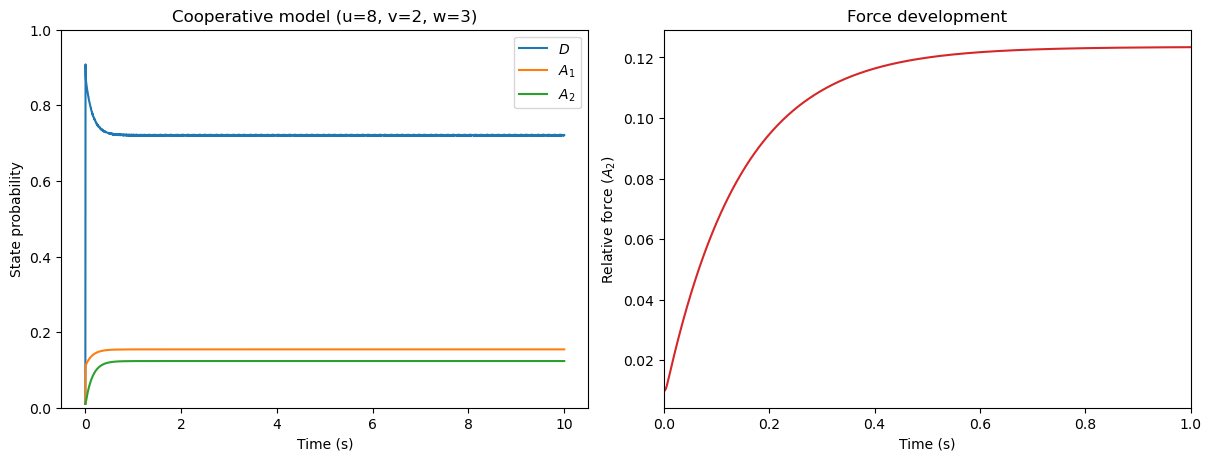

In [ ]:
# Solve the cooperative model
t_span = (0, 10)
t_eval = np.linspace(*t_span, 5000)
y0 = [0.01, 0.01, 0.01]

sol = solve_ivp(
    rhs_cooperative,
    t_span,
    y0,
    t_eval=t_eval,
    method="RK45",
    args=(Ca, u, v, w),
)

# Plot state probabilities
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(sol.t, sol.y[0], label=r"$D$")
axes[0].plot(sol.t, sol.y[1], label=r"$A_1$")
axes[0].plot(sol.t, sol.y[2], label=r"$A_2$")
axes[0].set(
    xlabel="Time (s)",
    ylabel="State probability",
    title=f"Cooperative model (u={u}, v={v}, w={w})",
    ylim=(0, 1),
)
axes[0].legend()

# Force development
A_2_sol = sol.y[2]
axes[1].plot(sol.t, A_2_sol, color="C3")
axes[1].set(
    xlabel="Time (s)",
    ylabel="Relative force ($A_2$)",
    title="Force development",
    xlim=(0, 1),
)

plt.show()